## 제품 유형 1 - 통계 => 이상치 제거하지 않았던 ML용 데이터로 실행해봄
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- 스피어만 상관계수 히트맵

In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [3]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_2 = pd.read_csv('../data/for_ML_process_data_product-2.csv')
df_sensor_2 = pd.read_csv('../data/for_ML_sensor_data_product-2.csv')
df_defects_2 = pd.read_csv('../data/for_ML_defects_data_product-2.csv')
df_original_2 = pd.read_csv('../data/for_ML_overall_product-2.csv')

In [4]:
# 2. 데이터 크기 확인
print(f"제품 2의 process 관련 데이터 크기: {df_process_2.shape}")
print(f"제품 2의 sensor 관련 데이터 크기: {df_sensor_2.shape}")
print(f"제품 2의 defects 관련 데이터 크기: {df_defects_2.shape}")

제품 2의 process 관련 데이터 크기: (3328, 16)
제품 2의 sensor 관련 데이터 크기: (3328, 7)
제품 2의 defects 관련 데이터 크기: (3328, 4)


---
### 2. 정규성 검정

#### 2.1 Shapiro-Wilk 검정

In [5]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):

    print(f"\n{'='*80}")
    print(f"제품 2의 {df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    result_list = []

    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()

        # 값이 1개뿐인 상수형 변수는 검정 불가
        if series.nunique() <= 1:
            result_list.append([col, np.nan, np.nan, "검정불가(상수형)"])
            continue

        stat, p_value = stats.shapiro(series)

        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        result_list.append([col, stat, p_value, result])

    # 결과표 생성
    shapiro_df = pd.DataFrame(result_list, columns=["변수명", "Shapiro 통계량", "p-value", "판정"])
    shapiro_df = shapiro_df.set_index("변수명")

    display(shapiro_df)

    return shapiro_df

In [6]:
shapiro_df_process = create_shapiro_summary(df_process_2, "process", exclude_cols=['shot_key'])


제품 2의 process 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
Unnamed: 0,0.954892,6.569707e-31,정규성 불만족
velocity_1,0.926543,1.316477e-37,정규성 불만족
velocity_2,0.969190,3.757826e-26,정규성 불만족
velocity_3,0.984859,2.096279e-18,정규성 불만족
high_velocity,0.648671,9.326014e-64,정규성 불만족
cylinder_pressure,0.253951,7.152509e-79,정규성 불만족
rapid_rise_time,0.760192,1.013079e-56,정규성 불만족
biscuit_thickness,0.889750,1.039510e-43,정규성 불만족
clamping_force,0.891286,1.720679e-43,정규성 불만족


In [7]:
shapiro_df_sensor = create_shapiro_summary(df_sensor_2, "sensor")


제품 2의 sensor 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
Unnamed: 0,0.954892,6.569707e-31,정규성 불만족
melting_furnace_temp,0.973086,1.449105e-24,정규성 불만족
air_pressure,0.943995,8.517212e-34,정규성 불만족
coolant_temp,0.971870,4.450284e-25,정규성 불만족
coolant_pressure,0.881055,6.652185e-45,정규성 불만족
factory_temp,0.788523,5.714469e-54,정규성 불만족
factory_humidity,0.863603,1.288867e-46,정규성 불만족


#### 2.2 Q-Q Plot

In [8]:
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

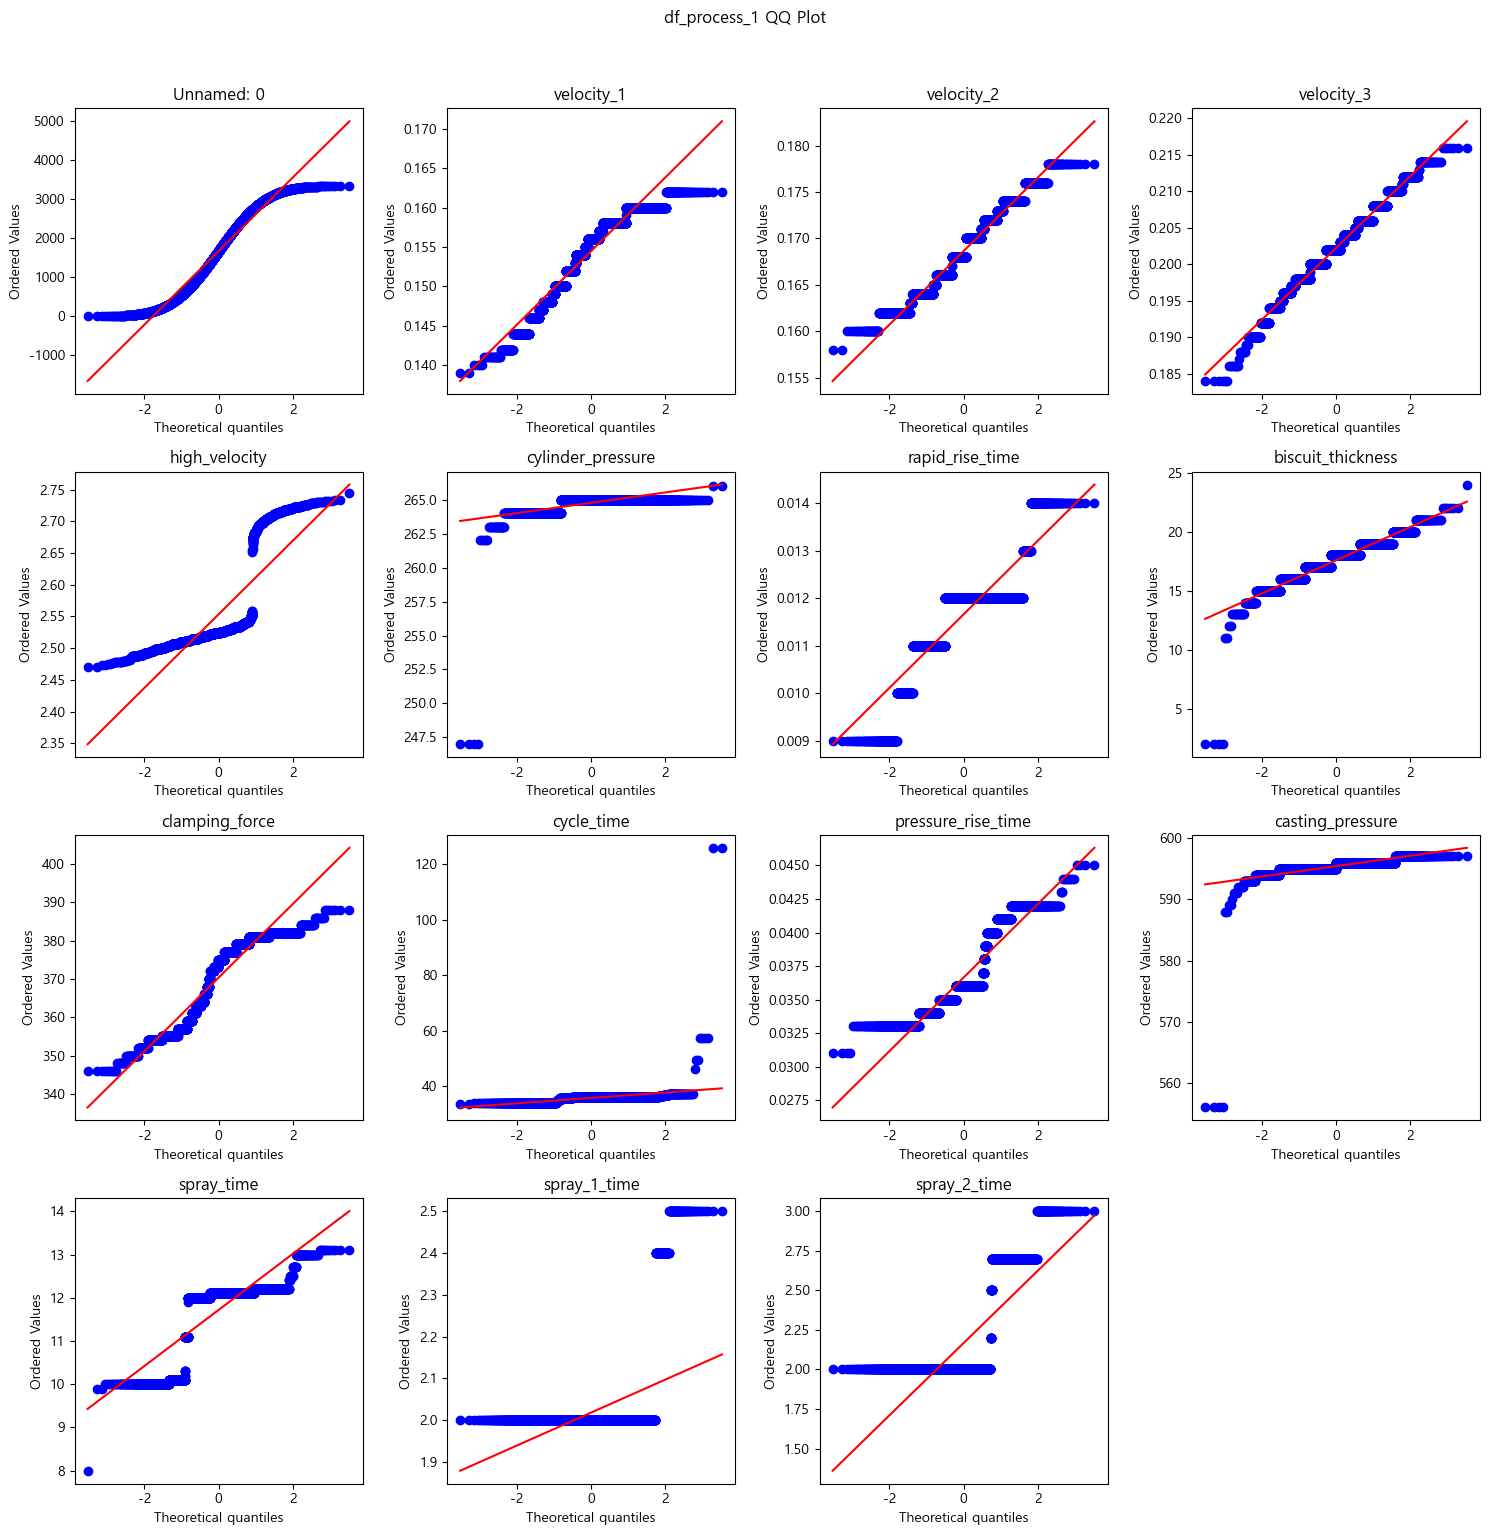

In [9]:
plot_qq_table(df_process_2, 
                title="df_process_1 QQ Plot",
                exclude_cols=[
                    "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 'clamping_force_outlier_flag', 'pressure_rise_time_outlier_flag',
                    'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'spray_2_time_outlier_flag',
                    'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag',  'velocity_2_outlier_flag',  'high_velocity_outlier_flag'], 
    )

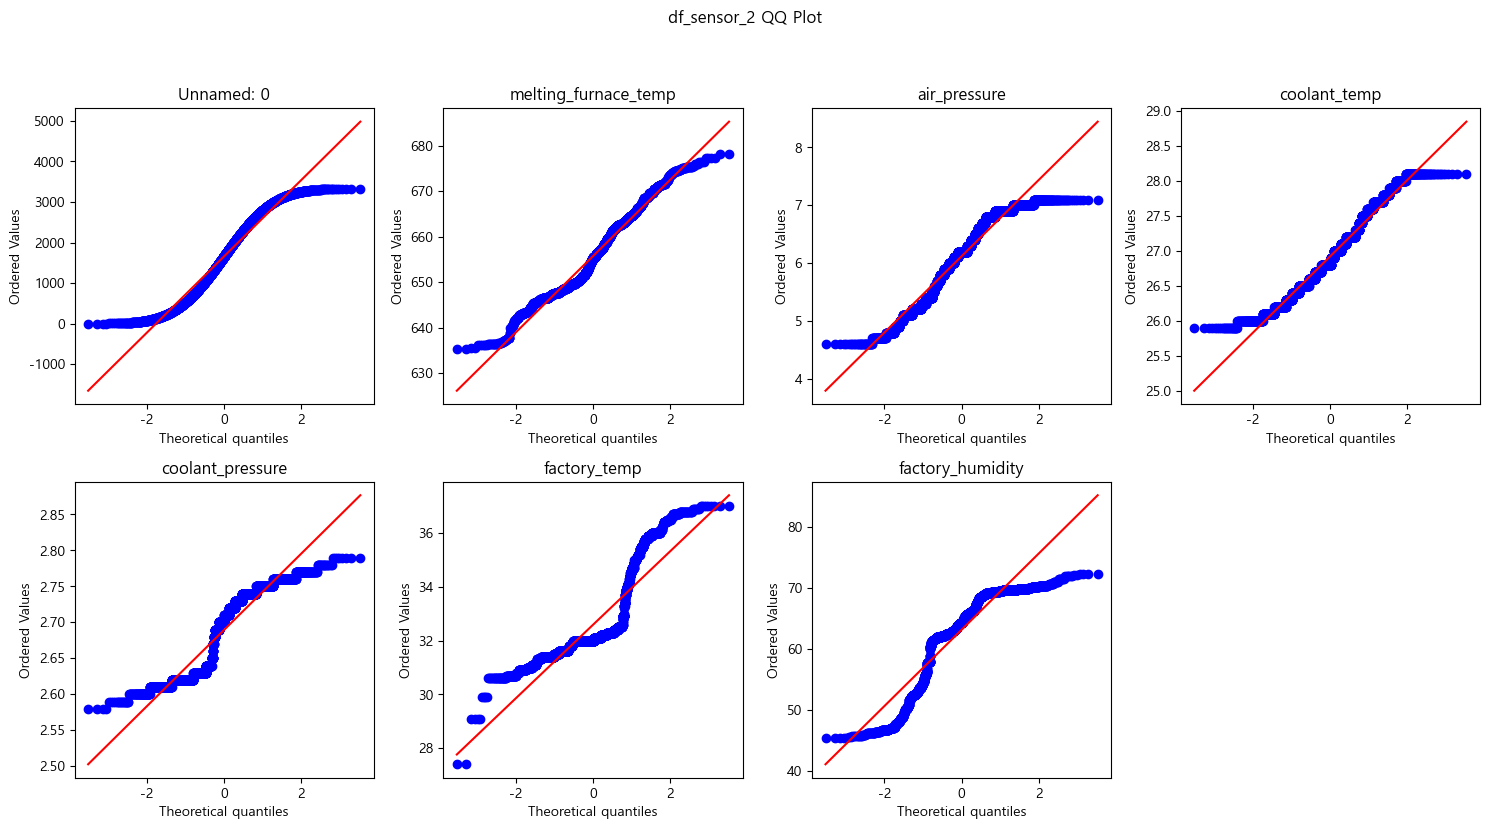

In [10]:
plot_qq_table(df_sensor_2, title="df_sensor_2 QQ Plot")

#### 2.3 Levene 검증

In [11]:
# 연속형 변수 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 연속형 변수 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기준 타깃 시리즈 가져오기
    target_series = defects_df[target_col]
    
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
        
        stat, p_value = stats.levene(group_0, group_1)
        
        if p_value >= alpha:
            result = "등분산 만족"
        else:
            result = "등분산 불만족"
        
        result_list.append([col, stat, p_value, result])
    
    # 결과표 생성
    levene_df = pd.DataFrame(
        result_list,
        columns=["변수명", "Levene 통계량", "p-value", "판정"]
    )
    levene_df = levene_df.set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [12]:
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2,
    "structural_defect",
    "df_process_1",
    exclude_cols=['shot_key',
        "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 'clamping_force_outlier_flag', 'pressure_rise_time_outlier_flag',
                    'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'spray_2_time_outlier_flag',
                    'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag',  'velocity_2_outlier_flag',  'high_velocity_outlier_flag', 
    ]
)


df_process_1 연속형 변수 등분산성 검정 (Levene test) - 기준: structural_defect



,Levene 통계량,p-value,판정
변수명,,,
Unnamed: 0,43.013461,6.279990e-11,등분산 불만족
velocity_1,6.549094,1.053763e-02,등분산 불만족
velocity_2,1.144535,2.847738e-01,등분산 만족
velocity_3,0.770437,3.801453e-01,등분산 만족
high_velocity,208.203514,7.973080e-46,등분산 불만족
cylinder_pressure,1.902790,1.678591e-01,등분산 만족
rapid_rise_time,2.453310,1.173724e-01,등분산 만족
biscuit_thickness,1.192678,2.748691e-01,등분산 만족
clamping_force,144.993082,1.022507e-32,등분산 불만족


In [13]:
process_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2,
    "structural_defect",
    "df_sensor_1",
    exclude_cols=['shot_key',
        "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 'clamping_force_outlier_flag', 'pressure_rise_time_outlier_flag',
                    'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'spray_2_time_outlier_flag',
                    'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag',  'velocity_2_outlier_flag',  'high_velocity_outlier_flag', 
    ]
)


df_sensor_1 연속형 변수 등분산성 검정 (Levene test) - 기준: structural_defect



,Levene 통계량,p-value,판정
변수명,,,
Unnamed: 0,43.013461,6.279990e-11,등분산 불만족
melting_furnace_temp,12.164641,4.933525e-04,등분산 불만족
air_pressure,1.067727,3.015346e-01,등분산 만족
coolant_temp,14.275245,1.606951e-04,등분산 불만족
coolant_pressure,4.739183,2.955317e-02,등분산 불만족
factory_temp,115.549928,1.662279e-26,등분산 불만족
factory_humidity,188.688952,8.929975e-42,등분산 불만족


#### 상관계수 히트맵

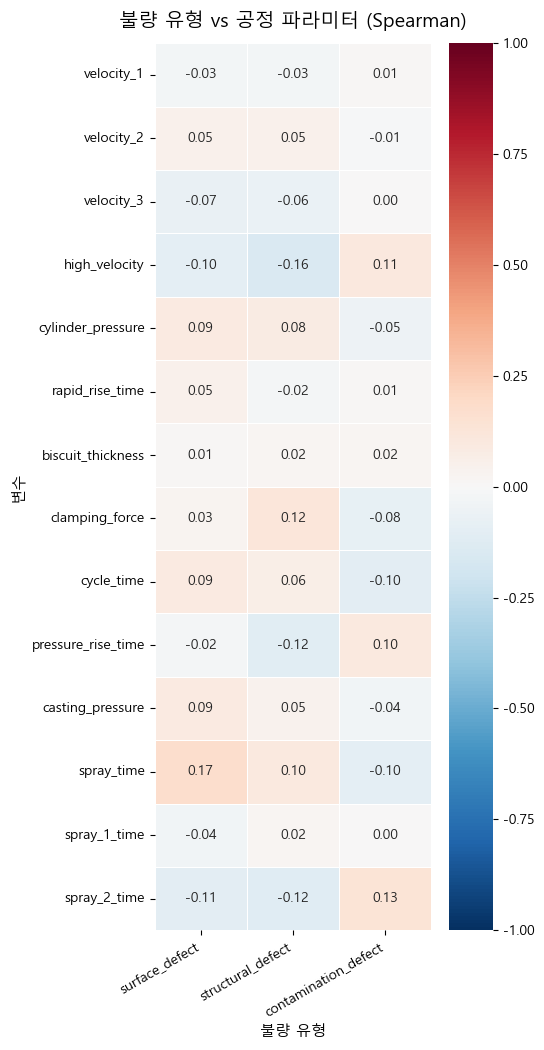

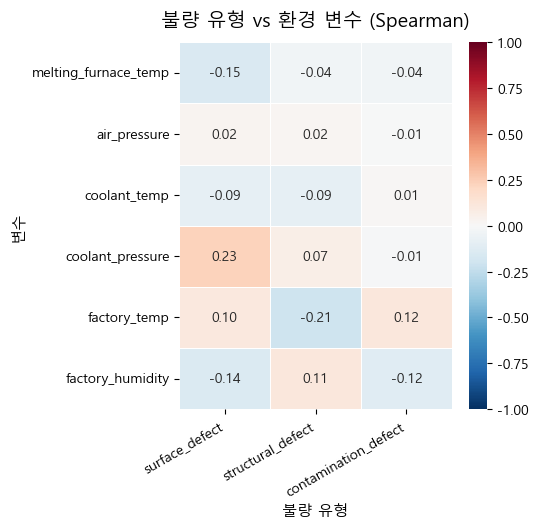

In [14]:
DEFECT_COLS = [
    'surface_defect',
    'structural_defect',
    'contamination_defect'
]

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 출력
plot_corr_heatmap(df_original_2, DEFECT_COLS, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2, DEFECT_COLS, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')